# S3_permutation_mine — MINE Metrics Permutation Test

Runs the same permutation test framework as S3, but for MINE metrics
(MIC, MAS, MEV, MCN, MIC−r²).

**Key facts:**
- `minepy.MINE.compute_score()` computes ALL metrics in one call
  (MIC, MAS, MEV, MCN are all derived from the same mutual-information grid),
  so computing one vs all has the **same cost**.
- The CONFIG switch below controls which metrics participate in the
  **joint test and analysis**, not the raw computation.
- Case subset modes let you run a quick test before committing to the full 114K.

| Mode | Cases | Est. time | Use case |
|------|-------|-----------|----------|
| `quick` | ~1,000 | ~1.5 h | Sanity check, see if MIC adds value |
| `medium` | ~5,000 | ~8 h | Solid comparison with S3 |
| `large` | ~10,000 | ~15 h | Higher confidence |
| `xlarge` | ~20,000 | ~31 h | Near-full coverage |
| `full` | 114,176 | ~176 h | Complete analysis |

*Times based on measured ~5.5s/case.*

**Environment:** pip39 (minepy 1.2.6)

In [36]:
# ============================================================
# CONFIG — Edit this cell to control the run
# ============================================================

# --- Subset mode ---
# 'quick'  : ~1,000 cases (~1.5 h) — all Null/VarOnly + sampled signal
# 'medium' : ~5,000 cases (~8 h)   — all Null/VarOnly + more signal
# 'large'  : ~10,000 cases (~15 h) — higher confidence
# 'xlarge' : ~20,000 cases (~31 h) — near-full coverage
# 'full'   : all 114,176 cases (~176 h)
SUBSET_MODE = 'large'

# --- Which MINE metrics to include in the joint test? ---
# All are computed regardless (single compute_score call),
# but only selected ones enter Z-score / joint test / classification.
USE_MIC    = True
USE_MAS    = False
USE_MEV    = False
USE_MCN    = False
USE_MIC_R2 = False    # MIC minus pearson r²

# --- Permutation parameters (match S3) ---
N_PERM = 500

# --- Checkpoint frequency (save every N cases) ---
CHECKPOINT_EVERY = 500

# --- Seed offset (avoid collision with S3/S4 seeds) ---
SEED_BASE = 200_000_000

# --- Resume from last checkpoint? ---
RESUME = True

# --- Build selected list ---
selected = []
if USE_MIC:    selected.append('MIC')
if USE_MAS:    selected.append('MAS')
if USE_MEV:    selected.append('MEV')
if USE_MCN:    selected.append('MCN')
if USE_MIC_R2: selected.append('MIC_r2')
print(f'Subset mode: {SUBSET_MODE}')
print(f'Selected metrics for joint test: {selected}')

Subset mode: large
Selected metrics for joint test: ['MIC']


In [37]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from minepy import MINE

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

DATA_DIR = Path('generated_scatterplot_data')
S3_DIR   = DATA_DIR / 'full' / 'S3'
OUT_DIR  = DATA_DIR / 'full' / 'S3_mine' / f'S3_mine_{SUBSET_MODE}'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output → {OUT_DIR}')

Output → generated_scatterplot_data/full/S3_mine/S3_mine_large


In [38]:
# Load raw (x, y) arrays and build subset
print('Loading scatter_points.npz ...')
pts = np.load(DATA_DIR / 'scatter_points.npz')
x_full = pts['x']   # (114176, 500)
y_full = pts['y']   # (114176, 500)
n_full, n_points = x_full.shape

# Load case metadata for stratified sampling
cases = pd.read_csv(DATA_DIR / 'cases.csv', low_memory=False)
is_null_func = cases['family_id'] == 'Null'
is_const_spread = cases['spread_pattern'] == 'constant'
cases['category'] = 'mean+variance'
cases.loc[is_null_func & is_const_spread, 'category'] = 'true_null'
cases.loc[~is_null_func & is_const_spread, 'category'] = 'mean_only'
cases.loc[is_null_func & ~is_const_spread, 'category'] = 'variance_only'

# --- Build subset indices ---
if SUBSET_MODE == 'full':
    subset_idx = np.arange(n_full)
else:
    rng_sub = np.random.default_rng(42)
    # Always keep ALL True Null (32) and ALL Variance-only (96) — rare & important
    rare_mask = cases['category'].isin(['true_null', 'variance_only'])
    rare_idx = np.where(rare_mask)[0]

    # Sample from Mean-only and Mean+Variance
    mo_idx = np.where(cases['category'] == 'mean_only')[0]
    mv_idx = np.where(cases['category'] == 'mean+variance')[0]

    if SUBSET_MODE == 'quick':
        n_mo, n_mv = 300, 572            # ~1,000 total
    elif SUBSET_MODE == 'medium':
        n_mo, n_mv = 1500, 3372          # ~5,000 total
    elif SUBSET_MODE == 'large':
        n_mo, n_mv = 2500, 7372          # ~10,000 total
    elif SUBSET_MODE == 'xlarge':
        n_mo, n_mv = 5000, 14872         # ~20,000 total
    else:
        raise ValueError(f'Unknown SUBSET_MODE: {SUBSET_MODE}')

    mo_sample = rng_sub.choice(mo_idx, size=min(n_mo, len(mo_idx)), replace=False)
    mv_sample = rng_sub.choice(mv_idx, size=min(n_mv, len(mv_idx)), replace=False)
    subset_idx = np.sort(np.concatenate([rare_idx, mo_sample, mv_sample]))

# Apply subset
x_all = x_full[subset_idx]
y_all = y_full[subset_idx]
case_ids = subset_idx  # original case_id in the full 114K dataset
n_cases = len(subset_idx)
cases_sub = cases.iloc[subset_idx].reset_index(drop=True)

print(f'Loaded: {n_full:,} total cases × {n_points} points')
print(f'Subset: {n_cases:,} cases ({SUBSET_MODE} mode)')
print(f'  Estimated time: ~{n_cases * 5.5 / 3600:.1f} hours')
print()
print('Subset composition:')
print(cases_sub['category'].value_counts().to_string())

# Load Pearson from S3 (for MIC−r²)
if USE_MIC_R2:
    p1 = np.load(S3_DIR / '_perm_phase1.npz')
    pearson_obs_s3 = p1['pearson_obs'][subset_idx]
    pearson_null_s3 = p1['pearson_null'][subset_idx]
    print(f'\nLoaded Pearson from S3 for MIC−r² (subset applied)')
else:
    pearson_obs_s3 = None
    pearson_null_s3 = None

Loading scatter_points.npz ...
Loaded: 114,176 total cases × 500 points
Subset: 10,000 cases (large mode)
  Estimated time: ~15.3 hours

Subset composition:
category
mean+variance    7372
mean_only        2500
variance_only      96
true_null          32


## Phase 1 — Compute MINE Observed + Null

For each case:
1. Compute MINE on original (x, y) → observed MIC, MAS, MEV, MCN
2. For each of 500 permutations of y, compute MINE → null distributions

Checkpoints saved to `_mine_checkpoint_NNNNN.npz` every 1,000 cases.

In [39]:
def compute_mine(x, y):
    """Compute all MINE metrics for a single (x, y) pair."""
    m = MINE()
    m.compute_score(x, y)
    return m.mic(), m.mas(), m.mev(), m.mcn()


def generate_perms(n, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(n) for _ in range(n_perm)])


# Test
mic, mas, mev, mcn = compute_mine(x_all[0], y_all[0])
print(f'Test case 0: MIC={mic:.4f}, MAS={mas:.4f}, MEV={mev:.4f}, MCN={mcn:.4f}')

Test case 0: MIC=0.4148, MAS=0.1602, MEV=0.4148, MCN=5.3219


In [40]:
def save_checkpoint(idx, mic_obs, mas_obs, mev_obs, mcn_obs,
                    mic_null, mas_null, mev_null, mcn_null):
    """Save progress up to case idx (exclusive)."""
    path = OUT_DIR / f'_mine_ckpt_{SUBSET_MODE}_{idx:06d}.npz'
    np.savez_compressed(
        path,
        completed=idx,
        case_ids=case_ids[:idx],
        mic_obs=mic_obs[:idx], mas_obs=mas_obs[:idx],
        mev_obs=mev_obs[:idx], mcn_obs=mcn_obs[:idx],
        mic_null=mic_null[:idx], mas_null=mas_null[:idx],
        mev_null=mev_null[:idx], mcn_null=mcn_null[:idx],
    )
    print(f'  Checkpoint saved: {path.name} ({idx:,}/{n_cases:,})')


def find_latest_checkpoint():
    """Find the most recent checkpoint for current mode."""
    pattern = f'_mine_ckpt_{SUBSET_MODE}_*.npz'
    ckpts = sorted(OUT_DIR.glob(pattern))
    if not ckpts:
        return 0, None
    latest = ckpts[-1]
    data = np.load(latest)
    idx = int(data['completed'])
    print(f'  Resuming from: {latest.name} ({idx:,}/{n_cases:,} completed)')
    return idx, data


print('Checkpoint utilities ready')

Checkpoint utilities ready


In [41]:
# Allocate arrays
mic_obs  = np.empty(n_cases, dtype=np.float64)
mas_obs  = np.empty(n_cases, dtype=np.float64)
mev_obs  = np.empty(n_cases, dtype=np.float64)
mcn_obs  = np.empty(n_cases, dtype=np.float64)
mic_null = np.empty((n_cases, N_PERM), dtype=np.float32)
mas_null = np.empty((n_cases, N_PERM), dtype=np.float32)
mev_null = np.empty((n_cases, N_PERM), dtype=np.float32)
mcn_null = np.empty((n_cases, N_PERM), dtype=np.float32)

# Resume from checkpoint?
start_idx = 0
if RESUME:
    start_idx, ckpt_data = find_latest_checkpoint()
    if ckpt_data is not None:
        mic_obs[:start_idx]  = ckpt_data['mic_obs']
        mas_obs[:start_idx]  = ckpt_data['mas_obs']
        mev_obs[:start_idx]  = ckpt_data['mev_obs']
        mcn_obs[:start_idx]  = ckpt_data['mcn_obs']
        mic_null[:start_idx] = ckpt_data['mic_null']
        mas_null[:start_idx] = ckpt_data['mas_null']
        mev_null[:start_idx] = ckpt_data['mev_null']
        mcn_null[:start_idx] = ckpt_data['mcn_null']

remaining = n_cases - start_idx
print(f'Starting from case {start_idx:,}, {remaining:,} remaining')
print(f'Estimated time: ~{remaining * 5.5 / 3600:.1f} hours')

t0 = time.time()
for i in tqdm(range(start_idx, n_cases), desc='MINE permutation',
              initial=start_idx, total=n_cases):
    x = x_all[i]
    y = y_all[i]

    # Observed
    mic_obs[i], mas_obs[i], mev_obs[i], mcn_obs[i] = compute_mine(x, y)

    # Null (permuted)
    perms = generate_perms(n_points, N_PERM, SEED_BASE + i)
    for k in range(N_PERM):
        mic_k, mas_k, mev_k, mcn_k = compute_mine(x, y[perms[k]])
        mic_null[i, k] = mic_k
        mas_null[i, k] = mas_k
        mev_null[i, k] = mev_k
        mcn_null[i, k] = mcn_k

    # Checkpoint
    if (i + 1) % CHECKPOINT_EVERY == 0:
        elapsed = time.time() - t0
        done = i + 1 - start_idx
        rate = done / elapsed
        eta_h = (n_cases - i - 1) / rate / 3600 if rate > 0 else 0
        print(f'  [{i+1:>7,}/{n_cases:,}]  {rate:.2f} cases/s  ETA {eta_h:.1f} h')
        save_checkpoint(i + 1, mic_obs, mas_obs, mev_obs, mcn_obs,
                        mic_null, mas_null, mev_null, mcn_null)

# Final save
elapsed_total = (time.time() - t0) / 3600
print(f'\nPhase 1 done in {elapsed_total:.1f} hours')
save_checkpoint(n_cases, mic_obs, mas_obs, mev_obs, mcn_obs,
                mic_null, mas_null, mev_null, mcn_null)

Starting from case 0, 10,000 remaining
Estimated time: ~15.3 hours


MINE permutation:   5%|▌         | 500/10000 [50:52<19:59:11,  7.57s/it]

  [    500/10,000]  0.16 cases/s  ETA 16.1 h
  Checkpoint saved: _mine_ckpt_large_000500.npz (500/10,000)


MINE permutation:  10%|▉         | 999/10000 [1:46:57<17:47:27,  7.12s/it]

  [  1,000/10,000]  0.16 cases/s  ETA 16.1 h


...

MINE permutation: 100%|█████████▉| 9999/10000 [19:13:03<00:05,  5.65s/it]

  [ 10,000/10,000]  0.14 cases/s  ETA 0.0 h


MINE permutation: 100%|██████████| 10000/10000 [19:13:12<00:00,  6.92s/it]

  Checkpoint saved: _mine_ckpt_large_010000.npz (10,000/10,000)

Phase 1 done in 19.2 hours


  Checkpoint saved: _mine_ckpt_large_010000.npz (10,000/10,000)


In [42]:
# Save final arrays
out_name = f'_mine_perm_{SUBSET_MODE}.npz'
np.savez_compressed(
    OUT_DIR / out_name,
    case_ids=case_ids,
    mic_obs=mic_obs, mas_obs=mas_obs, mev_obs=mev_obs, mcn_obs=mcn_obs,
    mic_null=mic_null, mas_null=mas_null, mev_null=mev_null, mcn_null=mcn_null,
)
print(f'Saved final arrays → {OUT_DIR}/{out_name}')
print(f'  {n_cases:,} cases × {N_PERM} permutations × 4 MINE metrics')

# Clean up checkpoints for this mode
for ckpt in OUT_DIR.glob(f'_mine_ckpt_{SUBSET_MODE}_*.npz'):
    ckpt.unlink()
    print(f'  Removed {ckpt.name}')
print('Checkpoints cleaned up')

Saved final arrays → generated_scatterplot_data/full/S3_mine/S3_mine_large/_mine_perm_large.npz
  10,000 cases × 500 permutations × 4 MINE metrics
  Removed _mine_ckpt_large_001500.npz
  Removed _mine_ckpt_large_005000.npz
  Removed _mine_ckpt_large_009000.npz
  Removed _mine_ckpt_large_003500.npz
  Removed _mine_ckpt_large_007000.npz
  Removed _mine_ckpt_large_007500.npz
  Removed _mine_ckpt_large_003000.npz
  Removed _mine_ckpt_large_009500.npz
  Removed _mine_ckpt_large_005500.npz
  Removed _mine_ckpt_large_001000.npz
  Removed _mine_ckpt_large_000500.npz
  Removed _mine_ckpt_large_004000.npz
  Removed _mine_ckpt_large_008000.npz
  Removed _mine_ckpt_large_002500.npz
  Removed _mine_ckpt_large_006000.npz
  Removed _mine_ckpt_large_006500.npz
  Removed _mine_ckpt_large_002000.npz
  Removed _mine_ckpt_large_010000.npz
  Removed _mine_ckpt_large_008500.npz
  Removed _mine_ckpt_large_004500.npz
Checkpoints cleaned up


## Phase 2 — Derive MIC−r² (if selected)

MIC−r² = MIC − (Pearson r)². Uses Pearson from S3's Phase 1 NPZ.

In [43]:
if USE_MIC_R2:
    # MIC_r2 = MIC - r²
    # pearson_obs_s3 is |r| (already subset-indexed), so r² = pearson_obs_s3²
    mic_r2_obs = mic_obs - pearson_obs_s3 ** 2

    # Null: MIC_null - pearson_null²
    mic_r2_null = mic_null.astype(np.float64) - pearson_null_s3.astype(np.float64) ** 2
    mic_r2_null = mic_r2_null.astype(np.float32)

    print(f'MIC−r² computed ({n_cases:,} cases)')
    print(f'  Observed: mean={mic_r2_obs.mean():.4f}, std={mic_r2_obs.std():.4f}')
    print(f'  Null mean: {mic_r2_null.mean():.4f}')
else:
    mic_r2_obs = None
    mic_r2_null = None
    print('MIC−r² skipped (USE_MIC_R2 = False)')

MIC−r² skipped (USE_MIC_R2 = False)


## Phase 3 — Z-scores + Joint Test

Two modes:
1. **MINE-only joint test**: T = max(Z) over selected MINE metrics
2. **Combined with S3**: T = max(Z) over S3's 4 metrics + selected MINE metrics

In [44]:
def compute_z(obs, null):
    """Z-score: (obs - median(null)) / IQR(null), with fallback."""
    null_f64 = null.astype(np.float64)
    med = np.median(null_f64, axis=1)
    q75 = np.percentile(null_f64, 75, axis=1)
    q25 = np.percentile(null_f64, 25, axis=1)
    iqr = q75 - q25
    tiny = iqr < 1e-12
    iqr[tiny] = np.std(null_f64[tiny], axis=1) * 1.35
    still_tiny = iqr < 1e-12
    iqr[still_tiny] = 1.0
    z_obs = (obs - med) / iqr
    z_null = (null_f64 - med[:, None]) / iqr[:, None]
    return z_obs, z_null, med, iqr


# Compute Z-scores for all MINE metrics
mine_z = {}
mine_z_null = {}
mine_meta = {}

for name, obs, null in [('MIC', mic_obs, mic_null),
                         ('MAS', mas_obs, mas_null),
                         ('MEV', mev_obs, mev_null),
                         ('MCN', mcn_obs, mcn_null)]:
    z_o, z_n, med, iqr = compute_z(obs, null)
    mine_z[name] = z_o
    mine_z_null[name] = z_n
    mine_meta[name] = {'median': med, 'iqr': iqr}
    print(f'{name}: Z mean={z_o.mean():.2f}, Z std={z_o.std():.2f}')

if USE_MIC_R2:
    z_o, z_n, med, iqr = compute_z(mic_r2_obs, mic_r2_null)
    mine_z['MIC_r2'] = z_o
    mine_z_null['MIC_r2'] = z_n
    mine_meta['MIC_r2'] = {'median': med, 'iqr': iqr}
    print(f'MIC_r2: Z mean={z_o.mean():.2f}, Z std={z_o.std():.2f}')

MIC: Z mean=26.93, Z std=17.38
MAS: Z mean=4.47, Z std=66.01
MEV: Z mean=26.89, Z std=17.39
MCN: Z mean=-0.50, Z std=2.49


In [45]:
# --- MINE-only joint test ---
z_obs_stack = np.stack([mine_z[m] for m in selected])
z_null_stack = np.stack([mine_z_null[m] for m in selected])

T_obs_mine = z_obs_stack.max(axis=0)
T_null_mine = z_null_stack.max(axis=0)

p_mine = (np.sum(T_null_mine >= T_obs_mine[:, None], axis=1) + 1) / (N_PERM + 1)
clf_mine = np.where(p_mine <= 0.05, 'detectable',
           np.where(p_mine >= 0.10, 'not_detectable', 'uncertain'))

# Driver
driver_idx = z_obs_stack.argmax(axis=0)
driver_mine = np.array([selected[d] for d in driver_idx])

print(f'MINE-only joint test ({selected}):')
print(pd.Series(clf_mine).value_counts().to_string())

MINE-only joint test (['MIC']):
detectable        9604
not_detectable     328
uncertain           68


In [46]:
# --- Combined joint test: S3's 4 metrics + MINE selected ---
print('Loading S3 null arrays for combined test...')
p1 = np.load(S3_DIR / '_perm_phase1.npz')
p2 = np.load(S3_DIR / '_perm_phase2.npz')

# Apply same subset
s3_metrics = {
    'pearson':  (p1['pearson_obs'][subset_idx],  p1['pearson_null'][subset_idx]),
    'spearman': (p1['spearman_obs'][subset_idx], p1['spearman_null'][subset_idx]),
    'eta2':     (p1['eta2_obs'][subset_idx],     p1['eta2_null'][subset_idx]),
    'dcor':     (p2['dcor_obs'][subset_idx],     p2['dcor_null'][subset_idx]),
}

# Z-scores for S3 metrics (on subset)
s3_z = {}
s3_z_null = {}
for name, (obs, null) in s3_metrics.items():
    z_o, z_n, _, _ = compute_z(obs, null)
    s3_z[name] = z_o
    s3_z_null[name] = z_n

# Stack all: S3 (4) + MINE (selected)
all_names = ['pearson', 'spearman', 'dcor', 'eta2'] + selected
all_z_obs = np.stack([s3_z.get(m, mine_z.get(m)) for m in all_names])
all_z_null = np.stack([s3_z_null.get(m, mine_z_null.get(m)) for m in all_names])

T_obs_combined = all_z_obs.max(axis=0)
T_null_combined = all_z_null.max(axis=0)

p_combined = (np.sum(T_null_combined >= T_obs_combined[:, None], axis=1) + 1) / (N_PERM + 1)
clf_combined = np.where(p_combined <= 0.05, 'detectable',
               np.where(p_combined >= 0.10, 'not_detectable', 'uncertain'))

driver_idx_c = all_z_obs.argmax(axis=0)
driver_combined = np.array([all_names[d] for d in driver_idx_c])

print(f'\nCombined joint test ({all_names}):')
print(pd.Series(clf_combined).value_counts().to_string())

Loading S3 null arrays for combined test...

Combined joint test (['pearson', 'spearman', 'dcor', 'eta2', 'MIC']):
detectable        9860
not_detectable     111
uncertain           29


## Phase 4 — Results & Comparison

In [47]:
# Build results dataframe
results = pd.DataFrame({
    'case_id': case_ids,
    'category': cases_sub['category'].values,
    'family_id': cases_sub['family_id'].values,
    'snr': cases_sub['snr'].values,
    # Observed
    'mic_obs': mic_obs, 'mas_obs': mas_obs,
    'mev_obs': mev_obs, 'mcn_obs': mcn_obs,
    # Null stats
    'mic_null_median': mine_meta['MIC']['median'],
    'mic_null_iqr':    mine_meta['MIC']['iqr'],
    # Z-scores
    'z_MIC': mine_z['MIC'], 'z_MAS': mine_z['MAS'],
    'z_MEV': mine_z['MEV'], 'z_MCN': mine_z['MCN'],
})

if USE_MIC_R2:
    results['mic_r2_obs'] = mic_r2_obs
    results['z_MIC_r2'] = mine_z['MIC_r2']

# MINE-only test
results['T_mine'] = T_obs_mine
results['p_mine'] = p_mine
results['clf_mine'] = clf_mine
results['driver_mine'] = driver_mine

# Combined test
results['T_combined'] = T_obs_combined
results['p_combined'] = p_combined
results['clf_combined'] = clf_combined
results['driver_combined'] = driver_combined

out_pq = OUT_DIR / f'mine_permutation_test_{SUBSET_MODE}.parquet'
results.to_parquet(out_pq, index=False)
print(f'Saved → {out_pq}')
print(f'Shape: {results.shape}')

Saved → generated_scatterplot_data/full/S3_mine/S3_mine_large/mine_permutation_test_large.parquet
Shape: (10000, 22)


In [48]:
import matplotlib.pyplot as plt
%matplotlib inline

# Load S3 original classification (subset only)
s3_df = pd.read_parquet(S3_DIR / 'permutation_test.parquet')
s3_clf_sub = s3_df['classification'].values[subset_idx]

cats = ['true_null', 'mean_only', 'variance_only', 'mean+variance']
cat_labels = ['True Null (FPR↓)', 'Mean-only (↑)', 'Var-only (↑)', 'Mean+Var (↑)']
cat_arr = cases_sub['category'].values

print(f'=== Detection Rate Comparison ({SUBSET_MODE} mode, n={n_cases:,}) ===')
print(f'{"Category":>20s}  {"S3 (4 metrics)":>15s}  {"MINE-only":>12s}  {"Combined":>12s}')
print('-' * 65)
for cat in cats:
    mask = cat_arr == cat
    n_cat = mask.sum()
    s3_rate = (s3_clf_sub[mask] == 'detectable').mean()
    mine_rate = (clf_mine[mask] == 'detectable').mean()
    comb_rate = (clf_combined[mask] == 'detectable').mean()
    print(f'{cat:>20s}  {s3_rate:>14.1%}  {mine_rate:>11.1%}  {comb_rate:>11.1%}  (n={n_cat})')

=== Detection Rate Comparison (large mode, n=10,000) ===
            Category   S3 (4 metrics)     MINE-only      Combined
-----------------------------------------------------------------
           true_null           12.5%         6.2%        12.5%  (n=32)
           mean_only           96.5%        90.2%        96.4%  (n=2500)
       variance_only           96.9%        88.5%        95.8%  (n=96)
       mean+variance           99.8%        98.5%        99.7%  (n=7372)


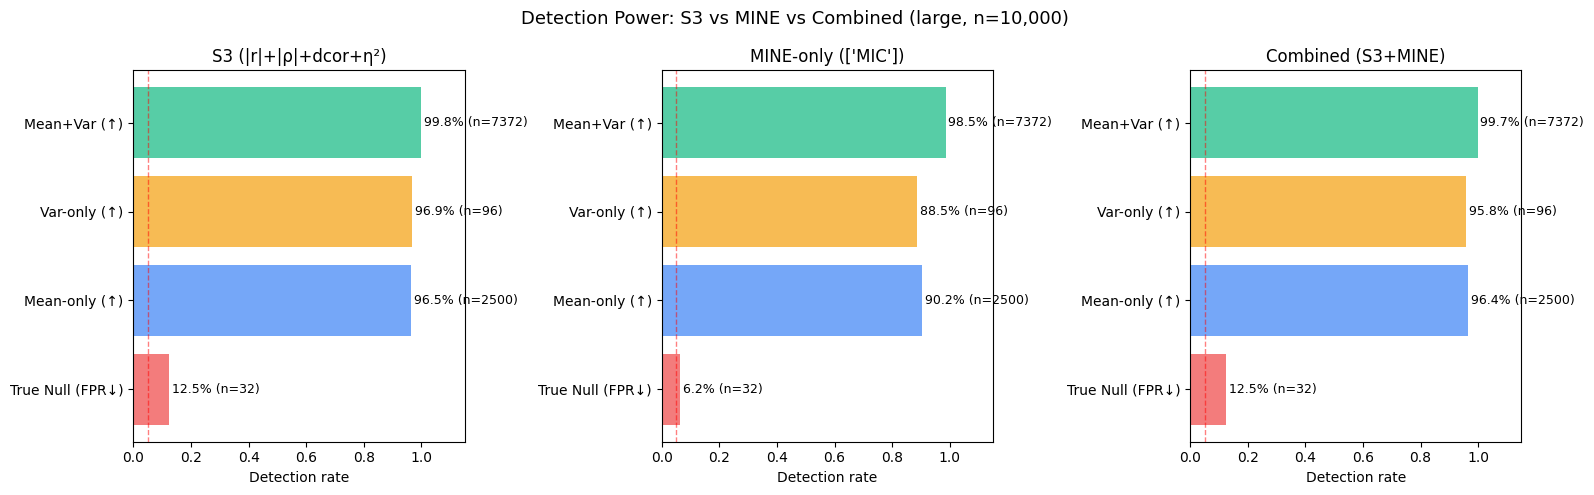

In [49]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (test_name, clf_arr) in zip(axes,
        [('S3 (|r|+|ρ|+dcor+η²)', s3_clf_sub),
         (f'MINE-only ({selected})', clf_mine),
         (f'Combined (S3+MINE)', clf_combined)]):
    rates = []
    for cat in cats:
        mask = cat_arr == cat
        rates.append((clf_arr[mask] == 'detectable').mean())
    colors = ['#ef4444', '#3b82f6', '#f59e0b', '#10b981']
    ax.barh(range(4), rates, color=colors, alpha=0.7)
    ax.set_yticks(range(4))
    ax.set_yticklabels(cat_labels)
    ax.set_xlabel('Detection rate')
    ax.set_title(test_name)
    ax.set_xlim(0, 1.15)
    ax.axvline(0.05, color='red', ls='--', lw=1, alpha=0.5)
    for i, r in enumerate(rates):
        n_cat = (cat_arr == cats[i]).sum()
        ax.text(r + 0.01, i, f'{r:.1%} (n={n_cat})', va='center', fontsize=9)

plt.suptitle(f'Detection Power: S3 vs MINE vs Combined ({SUBSET_MODE}, n={n_cases:,})', fontsize=13)
plt.tight_layout()
fig.savefig(OUT_DIR / f'mine_vs_s3_{SUBSET_MODE}.png', bbox_inches='tight')
plt.show()

In [50]:
# In the combined test, how often does a MINE metric drive detection?
det_mask = clf_combined == 'detectable'
print(f'Combined test: driver metric distribution (among {det_mask.sum():,} detectable cases):')
print(pd.Series(driver_combined[det_mask]).value_counts().to_string())
print()
print('→ If MINE metrics rarely drive detection, they add little value.')
print('→ If they frequently drive, they capture signals the original 4 miss.')

Combined test: driver metric distribution (among 9,860 detectable cases):
eta2       7887
dcor       1806
MIC         154
pearson      13

→ If MINE metrics rarely drive detection, they add little value.
→ If they frequently drive, they capture signals the original 4 miss.


In [51]:
# MINE null baseline analysis
# Confirm MIC's high positive bias under H₀
tn_mask = cat_arr == 'true_null'
print(f'MINE metrics under True Null (n={tn_mask.sum()}):')
print(f'{"Metric":>8s}  {"Obs mean":>10s}  {"Null median":>12s}  {"Null IQR":>10s}  {"Z mean":>8s}')
print('-' * 55)
for name, obs in [('MIC', mic_obs), ('MAS', mas_obs),
                   ('MEV', mev_obs), ('MCN', mcn_obs)]:
    print(f'{name:>8s}  {obs[tn_mask].mean():>10.4f}  '
          f'{mine_meta[name]["median"][tn_mask].mean():>12.4f}  '
          f'{mine_meta[name]["iqr"][tn_mask].mean():>10.4f}  '
          f'{mine_z[name][tn_mask].mean():>8.2f}')
print()
print('Note: MIC Null mean ~0.16 confirms high positive bias.')

MINE metrics under True Null (n=32):
  Metric    Obs mean   Null median    Null IQR    Z mean
-------------------------------------------------------
     MIC      0.1635        0.1614      0.0162      0.12
     MAS      0.0212        0.0168      0.0121      0.37
     MEV      0.1635        0.1614      0.0162      0.12
     MCN      5.3219        5.3219      1.0000      0.00

Note: MIC Null mean ~0.16 confirms high positive bias.


In [52]:
print('='*60)
print(f'SUMMARY ({SUBSET_MODE} mode)')
print('='*60)
print()
print(f'Cases: {n_cases:,} / {n_full:,} ({SUBSET_MODE})')
print(f'MINE metrics computed: MIC, MAS, MEV, MCN (all from one call)')
print(f'Selected for joint test: {selected}')
print(f'Permutations: {N_PERM}')
print()
print('Detection rates by category:')
print(f'{"":>20s}  {"S3 original":>12s}  {"MINE-only":>12s}  {"Combined":>12s}')
for cat in cats:
    mask = cat_arr == cat
    s3_r = (s3_clf_sub[mask] == 'detectable').mean()
    mi_r = (clf_mine[mask] == 'detectable').mean()
    co_r = (clf_combined[mask] == 'detectable').mean()
    print(f'{cat:>20s}  {s3_r:>11.1%}  {mi_r:>11.1%}  {co_r:>11.1%}')
print()
print('Key question: Does adding MINE improve detection power')
print('without inflating FPR (True Null)?')
print()
if SUBSET_MODE != 'full':
    print(f'→ This was a {SUBSET_MODE} run. If results look promising,')
    print(f'  change SUBSET_MODE to "medium" or "full" and rerun.')

SUMMARY (large mode)

Cases: 10,000 / 114,176 (large)
MINE metrics computed: MIC, MAS, MEV, MCN (all from one call)
Selected for joint test: ['MIC']
Permutations: 500

Detection rates by category:
                       S3 original     MINE-only      Combined
           true_null        12.5%         6.2%        12.5%
           mean_only        96.5%        90.2%        96.4%
       variance_only        96.9%        88.5%        95.8%
       mean+variance        99.8%        98.5%        99.7%

Key question: Does adding MINE improve detection power
without inflating FPR (True Null)?

→ This was a large run. If results look promising,
  change SUBSET_MODE to "medium" or "full" and rerun.
